# Example
## Rolling Metric 

An example showing the use of ```inspect.rolling_met```. 

This function is used to visualize how a metric is varies as a function of time. The metric is calculated using true ($y-true$) and modeled ($y-mod$) values. In some cases depending on the metric scores may be used instead of model values (e.g. ROC AUC).

The function uses ```pd.DataFrame.rolling``` to generate a set of windows with which a rolling metric can be calculated. The metric can be calculated using temporal windows and a timedelta or using an integer index. ```pd.DataFrame.rolling``` arguements are passed using the ```roll_kwargs``` keyword. For example:

```python
roll_kwargs = {'window'='90min', 'center':True, 'win_type':'gaussian'}
```

```inspect.rolling_met``` calculates the rolling metric for an arbitrary number of metrics which can be passed as callables (```lambdas```) using the ```roll_metric``` keyword. In this way users can calculate multiple metrics as well as set keyword parameters for each metric. For example:

```python
met1 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred)
# or
met2 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred, normalize=False)
# or 
met = [met1,met2]
# or
met = {'acc':met1,'acc_norm':met2}
```

The example here shows how the Median Absolute Error varies as function of geomagnetic conditions as measured by AE and Sym-H. The model file ```RF_FI_GEO_OOS_CHAMP.hdf5``` contains the predicted and observed density along the CHAMP satellite orbit. The predicted density is from a random forest model of atmospheric neutral density at 400 km altitude. 

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os, sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics

path_dat = "E:\OneDrive\Phys4501\data\RF_FI_GEO_OOS_CHAMP.hdf5"
path_mod = os.path.normpath(os.getcwd()+'/../ml_fw/') # assumes current working directory is the ml_fw/Notebooks directory

# add the ml_fw module to Python Path and import what we need
sys.path.append(os.path.dirname(path_mod))

import ml_fw.inspect as inspect

In [2]:
# load the data set and calculate the residuals
dat = pd.read_hdf(path_dat)
dat.head(1)

,1300_02,43000_09,85550_13,94400_18,SYM_H index,AE,SatLat,cos_SatMagLT,sin_SatMagLT,cos_SatLon,sin_SatLon,400kmDensity,DateTime,storm,storm phase,400kmDensity_pred
105120,7.648391,10.081208,9.545769,9.306003,-5.0,23.0,43.7912,-0.58071,-0.81411,-0.036139,0.999347,3.659148,2003-01-01,1,2,4.227237


In [3]:
# focus on a large storm and
# setup values for the rolling calculation
sdate = '2005-08-21'
edate = '2005-08-30'

gd = (dat['DateTime'] > sdate) & (dat['DateTime'] <= edate)

rdat = dat[gd].copy()

y_true = '400kmDensity'
y_pred = '400kmDensity_pred'
on = 'DateTime'
rkwargs = {'window':'90min','center':True}
met = {'MedAE':lambda y_true, y_pred: metrics.median_absolute_error(y_true, y_pred),
       'MAE':lambda y_true, y_pred: metrics.mean_absolute_error(y_true, y_pred)}

In [4]:
r_met = inspect.rolling_met(rdat,y_true=y_true,y_pred=y_pred,on=on,
                        roll_kwargs=rkwargs, roll_metric=met)

Using passed metric


In [5]:
r_met.head(1)

,MedAE,MAE,DateTime
0,0.134296,0.111149,2005-08-21 00:05:00


<Axes: xlabel='DateTime', ylabel='Sym-H - nT'>

<Axes: xlabel='DateTime', ylabel='AE - nT'>

<Axes: xlabel='DateTime', ylabel='Density'>

<Axes: xlabel='DateTime', ylabel='Density'>

<Axes: xlabel='DateTime', ylabel='Density'>

<Axes: xlabel='DateTime', ylabel='MedAE'>

<Axes: xlabel='DateTime', ylabel='MAE'>

<Figure size 640x480 with 0 Axes>

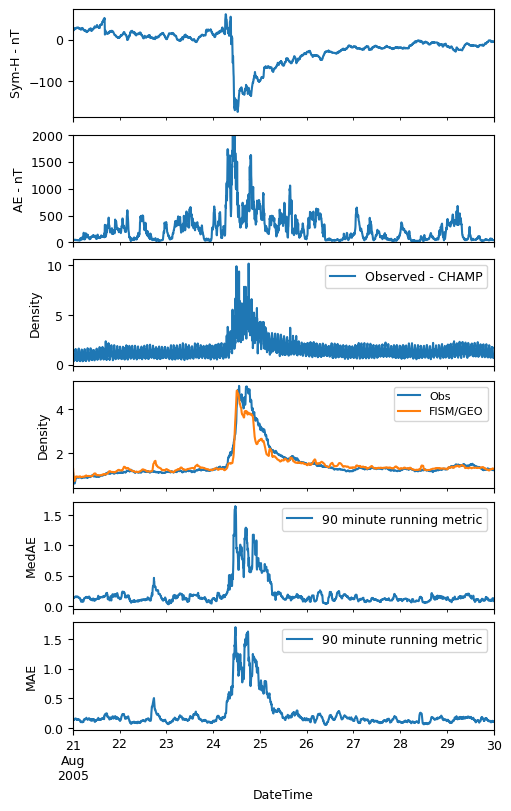

In [6]:
InteractiveShell.ast_node_interactivity = "last_expr"
plt.rcParams.update({'font.size': 9})
plt.subplots_adjust(hspace=0)
fig1, ax1 = plt.subplots(6,1,figsize=(5,8),sharex=True, layout='constrained')

pos = 0
rdat.plot(x='DateTime', y='SYM_H index', xlim=[sdate,edate], ax=ax1[pos], label='Sym-H', ylabel='Sym-H - nT', legend=False)
rdat.plot(x='DateTime', y='AE', xlim=[sdate,edate], ax=ax1[pos+1], label='AE', ylabel='AE - nT', legend=False, ylim=(0,2000))
rdat.plot(x='DateTime', y='400kmDensity', xlim=[sdate,edate], ax=ax1[pos+2], label='Observed - CHAMP', ylabel='Density', legend=True)

pos = 3
rdat[['DateTime','400kmDensity']].rolling('90min',on='DateTime').mean().plot(x='DateTime', y='400kmDensity', xlim=[sdate,edate], ax=ax1[pos], label='Obs', ylabel='Density', legend=False)
rdat[['DateTime','400kmDensity_pred']].rolling('90min',on='DateTime').mean().plot(x='DateTime', y='400kmDensity_pred', xlim=[sdate,edate], ax=ax1[pos], label='FISM/GEO', ylabel='Density', legend=False)
ax1[pos].legend(bbox_to_anchor=(1.,1),fontsize=8)

pos = 4
r_met.plot(x='DateTime', y='MedAE', xlim=[sdate,edate], ax=ax1[pos], label='90 minute running metric', ylabel='MedAE', legend=True)

pos = 5
r_met.plot(x='DateTime', y='MAE', xlim=[sdate,edate], ax=ax1[pos], label='90 minute running metric', ylabel='MAE', legend=True)
